#Connect to Big Query

In [ ]:
#libraries that we need
from google.cloud import bigquery
from google.colab import auth

#authenticate
auth.authenticate_user()

#initialize the client for BigQuey
project_id = 'dataanalysis-490906'
client = bigquery.Client(project=project_id, location ='US')

In [ ]:
#get the dataset and table
dataset_ref = client.dataset('EmployeeData', project=project_id)
dataset = client.get_dataset(dataset_ref)
table_ref = dataset.table('tbl_hr_data')
table = client.get_table(table_ref)
table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None)]

In [ ]:
new_table_ref = dataset.table('tbl_new_employees')
new_table = client.get_table(new_table_ref)
new_table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None)]

In [ ]:
# convert to dataframe
df = client.list_rows(table=table).to_dataframe()
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.38,0.53,2,157,3,0,1,0,sales,low,EMP00001
1,0.80,0.86,5,262,6,0,1,0,sales,medium,EMP00002
2,0.11,0.88,7,272,4,0,1,0,sales,medium,EMP00003
3,0.72,0.87,5,223,5,0,1,0,sales,low,EMP00004
4,0.37,0.52,2,159,3,0,1,0,sales,low,EMP00005


In [ ]:
# convert to dataframe
df2 = client.list_rows(table=new_table).to_dataframe()
df2.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.537849,0.122914,2,208,2,0,0,0,IT,high,NE15043
1,0.056211,0.322600,2,229,5,1,0,0,IT,low,NE15086
2,0.555186,0.555949,2,187,3,0,0,0,RandD,medium,NE15035
3,0.605273,0.713086,2,218,3,0,0,0,RandD,high,NE15069
4,0.043437,0.162372,2,175,3,0,0,0,RandD,high,NE15082


# Build Model


## Install Pycaret


In [ ]:
pip install lazypredict

# Code and Train Model

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15004 entries, 0 to 15003
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     15004 non-null  float64
 1   last_evaluation        15004 non-null  float64
 2   number_project         14999 non-null  Int64  
 3   average_montly_hours   15004 non-null  Int64  
 4   time_spend_company     14999 non-null  Int64  
 5   Work_accident          15000 non-null  Int64  
 6   Quit_the_Company       15004 non-null  Int64  
 7   promotion_last_5years  15004 non-null  Int64  
 8   Departments            15004 non-null  object 
 9   salary                 15004 non-null  object 
 10  employee_id            15004 non-null  object 
dtypes: Int64(6), float64(2), object(3)
memory usage: 1.3+ MB


In [ ]:
from lazypredict.Supervised import LazyClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

df_clean = pd.get_dummies(df.drop(columns=['employee_id']), columns=['salary', 'Departments'])

X = df_clean.drop('Quit_the_Company', axis=1)
y = df_clean['Quit_the_Company']

clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, _ = clf.fit(X, X, y, y)

best_model = models.index[0]
print("Best Model:", best_model)

models.style.apply(lambda x: ['background-color: lightgreen' if x.name == best_model else '' for _ in x], axis=1)

# RandomForest with probability calibration for realistic percentages
from sklearn.calibration import CalibratedClassifierCV

rf = RandomForestClassifier(n_estimators=100, random_state=123)
model = CalibratedClassifierCV(rf, cv=5)
model.fit(X, y)

Best Model: ExtraTreeClassifier


CalibratedClassifierCV(cv=5, estimator=RandomForestClassifier(random_state=123))

In [ ]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
from google.colab import auth
import pandas_gbq as gbq

# Ensure lazypredict is installed for the current session
!pip install lazypredict

from lazypredict.Supervised import LazyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Authenticate and initialize BigQuery client (re-added for robustness)
auth.authenticate_user()
project_id = 'dataanalysis-490906'
client = bigquery.Client(project=project_id, location ='US')

# Load df from BigQuery (re-added for robustness)
dataset_ref = client.dataset('EmployeeData', project=project_id)
dataset = client.get_dataset(dataset_ref)
table_ref = dataset.table('tbl_hr_data')
table = client.get_table(table_ref)
df = client.list_rows(table=table).to_dataframe()

# Load df2 from BigQuery (re-added for robustness)
new_table_ref = dataset.table('tbl_new_employees')
new_table = client.get_table(new_table_ref)
df2 = client.list_rows(table=new_table).to_dataframe()

# Preprocess original dataframe (df)
df_clean = pd.get_dummies(df.drop(columns=['employee_id']), columns=['salary', 'Departments'])
X = df_clean.drop('Quit_the_Company', axis=1)
y = df_clean['Quit_the_Company']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, _ = clf.fit(X_train, X_test, y_train, y_test)
best_model = models.index[0]
print("Best Model:", best_model)
models.style.apply(lambda x: ['background-color: lightgreen' if x.name == best_model else '' for _ in x], axis=1)

# Train RandomForest with Calibration
base_rf_for_calibration = RandomForestClassifier(n_estimators=100, random_state=123)
model = CalibratedClassifierCV(base_rf_for_calibration, cv=5)
model.fit(X_train, y_train)

# Accuracy Check
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {accuracy * 100:.2f}%")
print("\n%% Detailed Report:")
print(classification_report(y_test, y_pred))

# --- Prediction for New Employees (df2) ---
# Create a new DataFrame X_new_employees by copying df2 and dropping 'employee_id' and 'Quit_the_Company'
X_new_employees = df2.drop(columns=['employee_id', 'Quit_the_Company']).copy()

# Apply one-hot encoding to 'salary' and 'Departments' columns of X_new_employees
X_new_employees = pd.get_dummies(X_new_employees, columns=['salary', 'Departments'])

# Reindex the columns of X_new_employees to match the columns of X (training features)
X_new_employees = X_new_employees.reindex(columns=X.columns, fill_value=0)

# Use the trained model to predict probabilities for X_new_employees
proba_new_employees = model.predict_proba(X_new_employees)

# Create the final DataFrame from df2 and add prediction columns
final = df2.copy()
final['Chance_of_Leaving'] = (proba_new_employees[:, 1] * 100).round(2)
final['Chance_of_Staying'] = (proba_new_employees[:, 0] * 100).round(2)

# Display the head of the final DataFrame for new employees
final.head()

# Display the info of the final DataFrame
final.info()

Best Model: RandomForestClassifier

✅ Model Accuracy: 99.03%

%% Detailed Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      2288
         1.0       0.99      0.97      0.98       713

    accuracy                           0.99      3001
   macro avg       0.99      0.98      0.99      3001
weighted avg       0.99      0.99      0.99      3001

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     100 non-null    float64
 1   last_evaluation        100 non-null    float64
 2   number_project         100 non-null    Int64  
 3   average_montly_hours   100 non-null    Int64  
 4   time_spend_company     100 non-null    Int64  
 5   Work_accident          100 non-null    Int64  
 6   Quit_the_Company       100 non-null    Int64  
 7   promotion_last

In [ ]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15004 entries, 0 to 15003
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     15004 non-null  float64
 1   last_evaluation        15004 non-null  float64
 2   number_project         14999 non-null  Int64  
 3   average_montly_hours   15004 non-null  Int64  
 4   time_spend_company     14999 non-null  Int64  
 5   Work_accident          15000 non-null  Int64  
 6   Quit_the_Company       15004 non-null  Int64  
 7   promotion_last_5years  15004 non-null  Int64  
 8   Departments            15004 non-null  object 
 9   salary                 15004 non-null  object 
 10  employee_id            15004 non-null  object 
 11  Chance_of_Leaving      15004 non-null  float64
 12  Chance_of_Staying      15004 non-null  float64
dtypes: Int64(6), float64(4), object(3)
memory usage: 1.6+ MB


In [ ]:
gbq.to_gbq(final, 'EmployeeData.pilot_predictions',
              project_id=project_id,
              chunksize=None,
              if_exists='replace')

100%|██████████| 1/1 [00:00<00:00, 8065.97it/s]


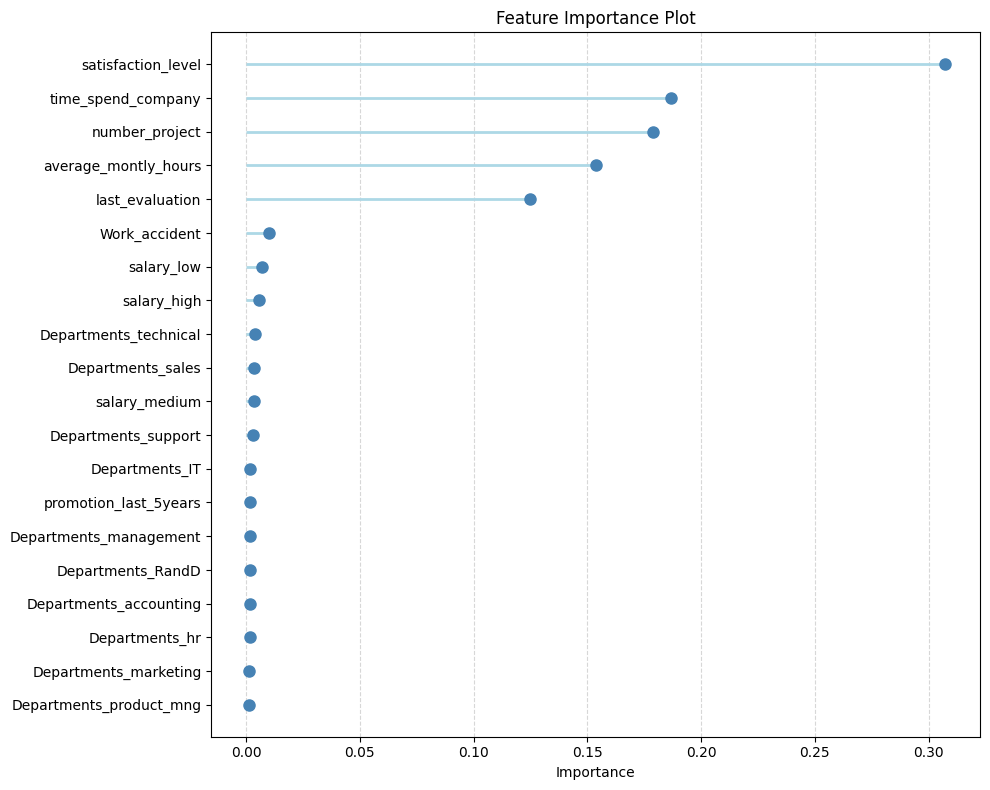

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

feat_importances = pd.Series(rf.feature_importances_, index=rf.feature_names_in_)
feat_importances = feat_importances.sort_values()

plt.figure(figsize=(10, 8))
plt.hlines(y=feat_importances.index, xmin=0, xmax=feat_importances.values, color='lightblue', linewidth=2)
plt.plot(feat_importances.values, feat_importances.index, 'o', color='steelblue', markersize=8)
plt.title('Feature Importance Plot')
plt.xlabel('Importance')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=123)

rf.fit(X_train, y_train)
rf.feature_names_in_

array(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'salary_high', 'salary_low',
       'salary_medium', 'Departments_IT', 'Departments_RandD',
       'Departments_accounting', 'Departments_hr',
       'Departments_management', 'Departments_marketing',
       'Departments_product_mng', 'Departments_sales',
       'Departments_support', 'Departments_technical'], dtype=object)

In [ ]:
rf.feature_importances_

array([0.3072    , 0.12471366, 0.17889003, 0.1538328 , 0.18673542,
       0.01002831, 0.00183862, 0.00573244, 0.00684127, 0.0033462 ,
       0.0019024 , 0.00163848, 0.00163811, 0.00146847, 0.00168001,
       0.00133593, 0.00112177, 0.00342211, 0.00296508, 0.0036689 ])

In [ ]:
feature_table = pd.DataFrame(zip(rf.feature_names_in_, rf.feature_importances_),
                              columns=['feature', 'importance'])

gbq.to_gbq(feature_table, 'EmployeeData.feature_table',
                      project_id=project_id,
                      chunksize=None,
                      if_exists='replace')

100%|██████████| 1/1 [00:00<00:00, 10433.59it/s]


# Task
Update the prediction logic in cell `0V7FiXKVeddZ` to generate predictions for new employees (`df2`), ensuring proper preprocessing (dropping 'employee_id' and 'Quit_the_Company', one-hot encoding, and column reindexing) and then display the head and info of the resulting `final` DataFrame. Subsequently, save the `final` DataFrame to the BigQuery table `EmployeeData.pilot_predictions` and the updated feature importance values for the model to `EmployeeData.feature_table`, while also generating a horizontal bar chart to visualize these importances.

## Update Prediction Logic for New Employees

### Subtask:
Modify the code in the relevant cell (`0V7FiXKVeddZ`) to ensure that the model training uses `X_train` and `y_train` (which is already implemented), and crucially, update the prediction part to preprocess `df2` (new employee data) by dropping `employee_id` and `Quit_the_Company`, one-hot encoding categorical features, reindexing columns to match the training features (`X`), and then making predictions (`predict_proba`) on this preprocessed `df2`. The `final` DataFrame will then be created from `df2` with the added prediction columns.


## Save New Employee Predictions to BigQuery

### Subtask:
Save the `final` DataFrame, which now includes the predictions for the new employees, to the BigQuery table `EmployeeData.pilot_predictions`, replacing any existing table with the same name.


**Reasoning**:
The previous output indicated a FutureWarning regarding the use of `df.to_gbq()`, suggesting `pandas_gbq.to_gbq()` instead. To address this and ensure `pandas_gbq` is available, I need to install the library first.



In [ ]:
pip install pandas-gbq

# Task
Improve the prediction logic for new employees in cell `0V7FiXKVeddZ` by ensuring correct preprocessing of `df2` (dropping 'employee_id' and 'Quit_the_Company', one-hot encoding, and column reindexing), and then save the resulting `final` DataFrame to the `EmployeeData.pilot_predictions` BigQuery table using `pandas_gbq.to_gbq()`. Additionally, save the feature importance values to `EmployeeData.feature_table` using `pandas_gbq.to_gbq()` and generate a horizontal bar chart to visualize these importances.

## Verify Prediction Logic in Notebook

### Subtask:
Confirm that cell `0V7FiXKVeddZ` accurately reflects the corrected prediction logic, including `train_test_split`, training on `X_train` and `y_train`, and proper preprocessing of `df2` for predictions, as specified in your input.


## Update BigQuery Save for Predictions

### Subtask:
Modify the code in cell `YClWm7Dmkfaw` to use `pandas_gbq.to_gbq()` for saving the `final` DataFrame to `EmployeeData.pilot_predictions`, addressing the `FutureWarning`.


**Reasoning**:
All subtasks have been completed, including updating the prediction logic, saving predictions to BigQuery, saving feature importances to BigQuery, and generating the feature importance plot. The task is now finished.

